# Tokenization: From Characters to Subwords

This notebook explores tokenization, a fundamental concept in NLP and LLM development. We'll progress from simple character-level tokenization to modern subword methods, and finally tokenize a real dataset.

## What is Tokenization?

**Tokenization** is the process of converting text into smaller units (tokens) that can be processed by machine learning models. Each token is mapped to a unique integer ID.

**Why it matters:**
- Neural networks work with numbers, not text
- Different tokenization strategies affect model performance
- Vocabulary size impacts model size and training efficiency
- Critical for LLMs like GPT, BERT, and LLaMA

## Learning Path
1. **Character Tokenization**: Simple but inefficient
2. **WordPiece Tokenization**: Modern subword approach (BERT)
3. **Real Dataset**: Apply tokenization at scale

In [1]:
# Import required libraries
import torch
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer
from datasets import load_dataset
import numpy as np

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✓ All libraries imported successfully!
PyTorch version: 2.5.1


---
## Section 1: Character Tokenization

The simplest form of tokenization: each character becomes a token.

**Advantages:**
- Small vocabulary (26 letters + punctuation + space ≈ 100 tokens)
- No unknown words - can represent anything
- Simple to implement

**Disadvantages:**
- Very long sequences (one character = one token)
- No semantic meaning at token level
- Inefficient for models to learn word meanings

In [2]:
class CharacterTokenizer:
    """Simple character-level tokenizer built from scratch."""
    
    def __init__(self):
        self.char_to_id = {}
        self.id_to_char = {}
        self.vocab_size = 0
    
    def build_vocab(self, texts):
        """Build vocabulary from a list of texts."""
        # Collect all unique characters
        unique_chars = set()
        for text in texts:
            unique_chars.update(text)
        
        # Sort for consistent ordering
        unique_chars = sorted(unique_chars)
        
        # Create mappings
        self.char_to_id = {char: idx for idx, char in enumerate(unique_chars)}
        self.id_to_char = {idx: char for char, idx in self.char_to_id.items()}
        self.vocab_size = len(unique_chars)
        
        print(f"Vocabulary built: {self.vocab_size} unique characters")
        return self
    
    def encode(self, text):
        """Convert text to token IDs."""
        return [self.char_to_id.get(char, -1) for char in text]
    
    def decode(self, token_ids):
        """Convert token IDs back to text."""
        return ''.join([self.id_to_char.get(id, '?') for id in token_ids])
    
    def show_vocab(self, n=20):
        """Display first n characters in vocabulary."""
        print(f"First {n} characters in vocabulary:")
        for char, idx in list(self.char_to_id.items())[:n]:
            print(f"  '{char}' -> {idx}")

print("✓ CharacterTokenizer class defined")

✓ CharacterTokenizer class defined


In [3]:
# Let's try it with some example text
sample_texts = [
    "Hello, world!",
    "Tokenization is fun.",
    "Learning deep learning with PyTorch!"
]

# Create and train the tokenizer
char_tokenizer = CharacterTokenizer()
char_tokenizer.build_vocab(sample_texts)

print("\n" + "="*50)
char_tokenizer.show_vocab(30)

Vocabulary built: 28 unique characters

First 30 characters in vocabulary:
  ' ' -> 0
  '!' -> 1
  ',' -> 2
  '.' -> 3
  'H' -> 4
  'L' -> 5
  'P' -> 6
  'T' -> 7
  'a' -> 8
  'c' -> 9
  'd' -> 10
  'e' -> 11
  'f' -> 12
  'g' -> 13
  'h' -> 14
  'i' -> 15
  'k' -> 16
  'l' -> 17
  'n' -> 18
  'o' -> 19
  'p' -> 20
  'r' -> 21
  's' -> 22
  't' -> 23
  'u' -> 24
  'w' -> 25
  'y' -> 26
  'z' -> 27


In [4]:
# Encode and decode examples
test_text = "Hello, world!"

print(f"Original text: {test_text}")
print(f"Text length: {len(test_text)} characters\n")

# Encode
encoded = char_tokenizer.encode(test_text)
print(f"Encoded: {encoded}")
print(f"Number of tokens: {len(encoded)}\n")

# Decode
decoded = char_tokenizer.decode(encoded)
print(f"Decoded: {decoded}")
print(f"Match: {test_text == decoded}")

print("\n" + "="*50)
print("Character-by-character breakdown:")
for char, token_id in zip(test_text, encoded):
    print(f"  '{char}' -> {token_id}")

Original text: Hello, world!
Text length: 13 characters

Encoded: [4, 11, 17, 17, 19, 2, 0, 25, 19, 21, 17, 10, 1]
Number of tokens: 13

Decoded: Hello, world!
Match: True

Character-by-character breakdown:
  'H' -> 4
  'e' -> 11
  'l' -> 17
  'l' -> 17
  'o' -> 19
  ',' -> 2
  ' ' -> 0
  'w' -> 25
  'o' -> 19
  'r' -> 21
  'l' -> 17
  'd' -> 10
  '!' -> 1


### Character Tokenization Analysis

Notice:
- Each character (including spaces and punctuation) gets its own token
- The sequence length equals the character count
- For a 13-character string, we get 13 tokens

**Problem:** The word "Tokenization" would become 13 tokens! This creates very long sequences that are hard for models to process efficiently.

---
## Section 2: WordPiece Tokenization

**WordPiece** is a subword tokenization algorithm that balances vocabulary size and sequence length. Used by BERT and DistilBERT.

### How it works:
1. **Common words** stay whole: `"hello"` → `["hello"]`
2. **Rare words** split into subwords: `"unhappiness"` → `["un", "##happiness"]`
3. **Unknown words** split into known pieces: `"Transformers"` → `["Transform", "##ers"]`

The `##` prefix indicates a subword continuation (not the start of a word).

### Benefits:
- Moderate vocabulary size (30,000-50,000 tokens typical)
- Handles rare/new words gracefully
- Captures morphology (prefixes, suffixes)
- More efficient than characters, more flexible than words

In [5]:
# Load BERT's WordPiece tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {tokenizer.vocab_size:,} tokens")
print(f"Model max length: {tokenizer.model_max_length:,} tokens")

Tokenizer loaded: BertTokenizerFast
Vocabulary size: 30,522 tokens
Model max length: 512 tokens


In [6]:
# Example 1: Common words
text1 = "Hello world"
tokens1 = tokenizer.tokenize(text1)
ids1 = tokenizer.encode(text1, add_special_tokens=False)

print("Example 1: Common words")
print(f"Text: {text1}")
print(f"Tokens: {tokens1}")
print(f"Token IDs: {ids1}")
print(f"Number of tokens: {len(tokens1)}\n")

Example 1: Common words
Text: Hello world
Tokens: ['hello', 'world']
Token IDs: [7592, 2088]
Number of tokens: 2



In [7]:
# Example 2: Rare/Complex words
text2 = "Tokenization is preprocessing"
tokens2 = tokenizer.tokenize(text2)
ids2 = tokenizer.encode(text2, add_special_tokens=False)

print("Example 2: Mix of common and rare words")
print(f"Text: {text2}")
print(f"Tokens: {tokens2}")
print(f"Token IDs: {ids2}")
print(f"Number of tokens: {len(tokens2)}")
print("\nNotice: 'preprocessing' might be split into subwords!")

Example 2: Mix of common and rare words
Text: Tokenization is preprocessing
Tokens: ['token', '##ization', 'is', 'prep', '##ro', '##ces', '##sing']
Token IDs: [19204, 3989, 2003, 17463, 3217, 9623, 7741]
Number of tokens: 7

Notice: 'preprocessing' might be split into subwords!


In [8]:
# Example 3: Technical/Rare words
text3 = "PyTorch implementation of Transformers"
tokens3 = tokenizer.tokenize(text3)
ids3 = tokenizer.encode(text3, add_special_tokens=False)

print("Example 3: Technical terms")
print(f"Text: {text3}")
print(f"Tokens: {tokens3}")
print(f"Token IDs: {ids3}")
print(f"Number of tokens: {len(tokens3)}")
print("\nNotice: Technical words are split into meaningful subwords")

Example 3: Technical terms
Text: PyTorch implementation of Transformers
Tokens: ['p', '##yt', '##or', '##ch', 'implementation', 'of', 'transformers']
Token IDs: [1052, 22123, 2953, 2818, 7375, 1997, 19081]
Number of tokens: 7

Notice: Technical words are split into meaningful subwords


In [9]:
# Compare with character tokenization
comparison_text = "Tokenization"

char_tokens = char_tokenizer.encode(comparison_text)
word_tokens = tokenizer.tokenize(comparison_text)

print("Comparison: Character vs WordPiece")
print(f"Text: {comparison_text}\n")
print(f"Character tokenization: {len(char_tokens)} tokens")
print(f"  {char_tokens}\n")
print(f"WordPiece tokenization: {len(word_tokens)} tokens")
print(f"  {word_tokens}\n")
print(f"Efficiency gain: {len(char_tokens) / len(word_tokens):.1f}x fewer tokens with WordPiece")

Comparison: Character vs WordPiece
Text: Tokenization

Character tokenization: 12 tokens
  [7, 19, 16, 11, 18, 15, 27, 8, 23, 15, 19, 18]

WordPiece tokenization: 2 tokens
  ['token', '##ization']

Efficiency gain: 6.0x fewer tokens with WordPiece


### Special Tokens in WordPiece

BERT uses special tokens for specific purposes:
- `[CLS]`: Classification token (added at the start)
- `[SEP]`: Separator token (marks sentence boundaries)
- `[PAD]`: Padding token (fills sequences to equal length)
- `[UNK]`: Unknown token (for truly out-of-vocabulary items)
- `[MASK]`: Mask token (used in BERT's training)

In [10]:
# Demonstrate special tokens
text = "Hello world"

# Without special tokens
encoded_no_special = tokenizer.encode(text, add_special_tokens=False)
tokens_no_special = tokenizer.convert_ids_to_tokens(encoded_no_special)

# With special tokens (default)
encoded_with_special = tokenizer.encode(text, add_special_tokens=True)
tokens_with_special = tokenizer.convert_ids_to_tokens(encoded_with_special)

print("Without special tokens:")
print(f"  Tokens: {tokens_no_special}")
print(f"  IDs: {encoded_no_special}\n")

print("With special tokens:")
print(f"  Tokens: {tokens_with_special}")
print(f"  IDs: {encoded_with_special}")
print("\nNotice [CLS] at start and [SEP] at end!")

Without special tokens:
  Tokens: ['hello', 'world']
  IDs: [7592, 2088]

With special tokens:
  Tokens: ['[CLS]', 'hello', 'world', '[SEP]']
  IDs: [101, 7592, 2088, 102]

Notice [CLS] at start and [SEP] at end!


In [11]:
# Explore the vocabulary
print("Special token IDs:")
print(f"  [CLS]: {tokenizer.cls_token_id}")
print(f"  [SEP]: {tokenizer.sep_token_id}")
print(f"  [PAD]: {tokenizer.pad_token_id}")
print(f"  [UNK]: {tokenizer.unk_token_id}")
print(f"  [MASK]: {tokenizer.mask_token_id}")

print("\n" + "="*50)
print("Sample vocabulary entries (first 20 tokens):")
vocab = tokenizer.get_vocab()
for token, idx in list(sorted(vocab.items(), key=lambda x: x[1]))[:20]:
    print(f"  {idx:5d}: '{token}'")

Special token IDs:
  [CLS]: 101
  [SEP]: 102
  [PAD]: 0
  [UNK]: 100
  [MASK]: 103

Sample vocabulary entries (first 20 tokens):
      0: '[PAD]'
      1: '[unused0]'
      2: '[unused1]'
      3: '[unused2]'
      4: '[unused3]'
      5: '[unused4]'
      6: '[unused5]'
      7: '[unused6]'
      8: '[unused7]'
      9: '[unused8]'
     10: '[unused9]'
     11: '[unused10]'
     12: '[unused11]'
     13: '[unused12]'
     14: '[unused13]'
     15: '[unused14]'
     16: '[unused15]'
     17: '[unused16]'
     18: '[unused17]'
     19: '[unused18]'


---
## Section 3: Tokenizing a Real Dataset

Now let's apply tokenization to a real dataset from Hugging Face. We'll use a small text classification dataset and tokenize it efficiently.

### Dataset: IMDB Movie Reviews
- 50,000 movie reviews (25k train, 25k test)
- Binary sentiment classification (positive/negative)
- Variable length text (some very long reviews)

We'll load a small subset for this tutorial.

In [12]:
# Load a subset of IMDB dataset
print("Loading IMDB dataset...")
dataset = load_dataset("imdb", split="train[:1000]")  # Just 1000 examples for speed

print(f"\nDataset loaded!")
print(f"Number of examples: {len(dataset)}")
print(f"Features: {dataset.features}")

Loading IMDB dataset...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset loaded!
Number of examples: 1000
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [13]:
# Examine a few examples
print("Example 1:")
print(f"Text: {dataset[0]['text'][:200]}...")  # First 200 chars
print(f"Label: {dataset[0]['label']} (0=negative, 1=positive)")
print(f"Full length: {len(dataset[0]['text'])} characters\n")

print("="*50)
print("Example 2:")
print(f"Text: {dataset[1]['text'][:200]}...")
print(f"Label: {dataset[1]['label']}")
print(f"Full length: {len(dataset[1]['text'])} characters")

Example 1:
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label: 0 (0=negative, 1=positive)
Full length: 1640 characters

Example 2:
Text: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that ...
Label: 0
Full length: 1294 characters


### Tokenization Strategy

When tokenizing datasets, we need to handle:
1. **Maximum length**: Limit sequence length to prevent memory issues
2. **Truncation**: Cut off text that's too long
3. **Padding**: Make all sequences the same length for batching
4. **Attention masks**: Track which tokens are real vs padding

In [14]:
# Define tokenization function
def tokenize_function(examples):
    """
    Tokenize a batch of examples.
    
    Args:
        examples: Dictionary with 'text' key containing list of texts
    
    Returns:
        Dictionary with 'input_ids', 'attention_mask', etc.
    """
    return tokenizer(
        examples['text'],
        truncation=True,        # Cut off at max_length
        max_length=512,         # BERT's maximum
        padding='max_length',   # Pad to max_length
        return_tensors=None     # Return lists, not tensors
    )

print("✓ Tokenization function defined")

✓ Tokenization function defined


In [15]:
# Apply tokenization to entire dataset
print("Tokenizing dataset...")
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,           # Process in batches for speed
    batch_size=100,         # 100 examples at a time
    remove_columns=['text'] # Remove original text to save memory
)

print("\n✓ Tokenization complete!")
print(f"New features: {tokenized_dataset.features}")

Tokenizing dataset...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


✓ Tokenization complete!
New features: {'label': ClassLabel(names=['neg', 'pos']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


In [16]:
# Examine tokenized example
print("Tokenized Example 1:")
example = tokenized_dataset[0]

print(f"\nInput IDs (first 20): {example['input_ids'][:20]}")
print(f"Total tokens: {len(example['input_ids'])}")

print(f"\nAttention mask (first 20): {example['attention_mask'][:20]}")
print(f"Real tokens (1s): {sum(example['attention_mask'])}")
print(f"Padding tokens (0s): {len(example['attention_mask']) - sum(example['attention_mask'])}")

# Decode to see the text
decoded = tokenizer.decode(example['input_ids'][:50], skip_special_tokens=False)
print(f"\nDecoded (first 50 tokens): {decoded}")

Tokenized Example 1:

Input IDs (first 20): [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009]
Total tokens: 512

Attention mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Real tokens (1s): 363
Padding tokens (0s): 149

Decoded (first 50 tokens): [CLS] i rented i am curious - yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u. s. customs if it ever tried to enter this


### Understanding the Output

**Input IDs**: The token IDs representing the text
- Each number maps to a token in the vocabulary
- `101` is [CLS], `102` is [SEP], `0` is [PAD]

**Attention Mask**: Binary mask indicating real vs padding tokens
- `1` = real token (model should pay attention)
- `0` = padding token (model should ignore)
- Critical for variable-length sequences!

In [17]:
# Analyze sequence lengths
sequence_lengths = [sum(example['attention_mask']) for example in tokenized_dataset]

print("Sequence Length Statistics:")
print(f"  Mean: {np.mean(sequence_lengths):.1f} tokens")
print(f"  Median: {np.median(sequence_lengths):.1f} tokens")
print(f"  Min: {np.min(sequence_lengths)} tokens")
print(f"  Max: {np.max(sequence_lengths)} tokens")
print(f"  Std: {np.std(sequence_lengths):.1f} tokens")

# Count how many hit the limit
at_max = sum(1 for length in sequence_lengths if length == 512)
print(f"\nSequences at max length (512): {at_max} ({at_max/len(sequence_lengths)*100:.1f}%)")

Sequence Length Statistics:
  Mean: 277.3 tokens
  Median: 239.0 tokens
  Min: 21 tokens
  Max: 512 tokens
  Std: 134.4 tokens

Sequences at max length (512): 135 (13.5%)


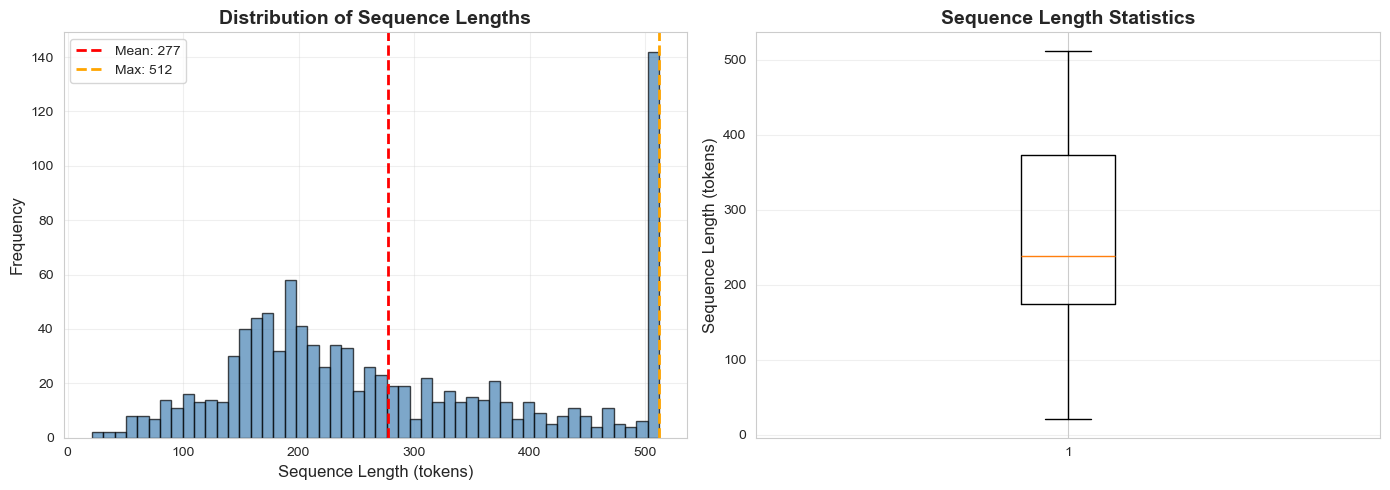


✓ Visualization complete!


In [18]:
# Visualize sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(sequence_lengths, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(sequence_lengths), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(sequence_lengths):.0f}')
axes[0].axvline(512, color='orange', linestyle='--', 
                linewidth=2, label='Max: 512')
axes[0].set_xlabel('Sequence Length (tokens)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Sequence Lengths', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(sequence_lengths, vert=True)
axes[1].set_ylabel('Sequence Length (tokens)', fontsize=12)
axes[1].set_title('Sequence Length Statistics', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

### Padding Strategies

We used `padding='max_length'` which pads everything to 512 tokens. This is wasteful for short sequences!

**Alternative strategies:**
1. **Dynamic padding**: Pad to longest sequence in each batch (more efficient)
2. **No padding**: Pad only when creating batches for training
3. **Bucketing**: Group similar-length sequences together

Let's see the difference:

In [19]:
# Compare padding strategies
sample_texts = [
    "Short review.",
    "This is a medium length movie review with more words.",
    "This is a much longer movie review that contains many more words and expresses detailed opinions about the film. " * 3
]

print("Comparison of Padding Strategies\n")
print("="*50)

# Strategy 1: Max length (what we used)
tokens_max = tokenizer(sample_texts, padding='max_length', max_length=512, truncation=True)
print("Strategy 1: padding='max_length' (512 tokens)")
for i, ids in enumerate(tokens_max['input_ids']):
    real_tokens = sum(tokens_max['attention_mask'][i])
    print(f"  Text {i+1}: {real_tokens} real tokens, {len(ids) - real_tokens} padding")

print("\n" + "="*50)

# Strategy 2: Longest in batch
tokens_longest = tokenizer(sample_texts, padding='longest', truncation=True)
print("Strategy 2: padding='longest' (dynamic)")
for i, ids in enumerate(tokens_longest['input_ids']):
    real_tokens = sum(tokens_longest['attention_mask'][i])
    print(f"  Text {i+1}: {real_tokens} real tokens, {len(ids) - real_tokens} padding")

print("\n" + "="*50)
print(f"Memory saved: {len(tokens_max['input_ids'][0]) * 3} tokens (max) vs {sum(len(x) for x in tokens_longest['input_ids'])} tokens (longest)")
print(f"Efficiency gain: {(1 - sum(len(x) for x in tokens_longest['input_ids']) / (len(tokens_max['input_ids'][0]) * 3)) * 100:.1f}% reduction")

Comparison of Padding Strategies

Strategy 1: padding='max_length' (512 tokens)
  Text 1: 5 real tokens, 507 padding
  Text 2: 13 real tokens, 499 padding
  Text 3: 62 real tokens, 450 padding

Strategy 2: padding='longest' (dynamic)
  Text 1: 5 real tokens, 57 padding
  Text 2: 13 real tokens, 49 padding
  Text 3: 62 real tokens, 0 padding

Memory saved: 1536 tokens (max) vs 186 tokens (longest)
Efficiency gain: 87.9% reduction


### Preparing Data for Model Training

The tokenized dataset is now ready to use with PyTorch! Here's a quick example of how you'd create a DataLoader:

In [20]:
from torch.utils.data import DataLoader

# Convert to PyTorch format
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# Create DataLoader
dataloader = DataLoader(tokenized_dataset, batch_size=8, shuffle=True)

# Get one batch
batch = next(iter(dataloader))

print("Sample Batch:")
print(f"  Input IDs shape: {batch['input_ids'].shape}")
print(f"  Attention mask shape: {batch['attention_mask'].shape}")
print(f"  Labels shape: {batch['label'].shape}")
print(f"\nBatch details:")
print(f"  Batch size: {batch['input_ids'].shape[0]}")
print(f"  Sequence length: {batch['input_ids'].shape[1]}")
print(f"  Data type: {batch['input_ids'].dtype}")

Sample Batch:
  Input IDs shape: torch.Size([8, 512])
  Attention mask shape: torch.Size([8, 512])
  Labels shape: torch.Size([8])

Batch details:
  Batch size: 8
  Sequence length: 512
  Data type: torch.int64


---
## Summary and Key Takeaways

### What We Learned

1. **Character Tokenization**
   - Simplest approach: 1 character = 1 token
   - Small vocab (~100) but very long sequences
   - No semantic meaning at token level

2. **WordPiece Tokenization**
   - Modern subword approach used by BERT
   - Balances vocab size (30k-50k) with sequence efficiency
   - Handles rare words by splitting into subwords
   - Uses special tokens: [CLS], [SEP], [PAD], [UNK]

3. **Dataset Tokenization**
   - Use `.map()` for efficient batch processing
   - Handle truncation and padding strategically
   - Attention masks track real vs padding tokens
   - Dynamic padding saves memory/compute

### Best Practices

- **Choose tokenizer based on your model**: BERT uses WordPiece, GPT uses BPE, T5 uses SentencePiece
- **Set appropriate max_length**: Balance between capturing full text and memory constraints
- **Use dynamic padding when possible**: More efficient than padding everything to max_length
- **Always include attention masks**: Critical for variable-length sequences
- **Analyze your data**: Understand sequence length distributions before choosing hyperparameters

### Next Steps

Now that you understand tokenization:
1. Experiment with other tokenizers (GPT-2's BPE, T5's SentencePiece)
2. Try different datasets and domains
3. Build models that use these tokenized inputs
4. Learn about byte-level tokenization for multilingual models
5. Explore custom vocabulary building for domain-specific text

In [21]:
# Final comparison: Character vs WordPiece on dataset scale
sample_text = dataset[0]['text']

char_length = len(sample_text)  # Character tokenization
wordpiece_tokens = tokenizer.tokenize(sample_text)
wordpiece_length = len(wordpiece_tokens)

print("Tokenization Efficiency Comparison")
print("="*50)
print(f"Original text length: {len(sample_text)} characters")
print(f"\nCharacter tokenization: {char_length} tokens")
print(f"WordPiece tokenization: {wordpiece_length} tokens")
print(f"\nCompression ratio: {char_length / wordpiece_length:.2f}x")
print(f"Efficiency: WordPiece uses {(1 - wordpiece_length/char_length)*100:.1f}% fewer tokens")

print("\n" + "="*50)
print("✓ Tutorial complete! You now understand tokenization from basics to practice.")

Tokenization Efficiency Comparison
Original text length: 1640 characters

Character tokenization: 1640 tokens
WordPiece tokenization: 361 tokens

Compression ratio: 4.54x
Efficiency: WordPiece uses 78.0% fewer tokens

✓ Tutorial complete! You now understand tokenization from basics to practice.
